# Clase 14: Algoritmos de Clasificación Supervisada 1

Recordemos que los algoritmos supervisados aprenden la relación entre variables de entrada y salidas conocidas a partir de ejemplos etiquetados. Entre los más utilizados se encuentran la regresión logística, que modela probabilidades de clasificación; las máquinas de soporte vectorial (SVM), que buscan fronteras óptimas entre clases; k-Nearest Neighbors (kNN), que clasifica según ejemplos similares; los árboles de decisión, que generan reglas jerárquicas de clasificación; y los Random Forest, que combinan múltiples árboles para obtener modelos más robustos y precisos. Aunque las redes neuronales también son parte de estos algoritmos, popularmente se consideran como pertenecientes a un subconjunto llamado Aprendizaje Profundo (*Deep Learning*).

[Ejemplo visual](https://narrative-flow.github.io/exploratory-study-2/)

## Regresión logística (Logistic Regression)

- Modela la probabilidad de pertenencia a una clase.

- Utiliza una combinación lineal de las variables de entrada seguida de una función logística (sigmoide - paso).

- Produce probabilidades interpretables.

- Funciona bien cuando las clases son aproximadamente separables de forma lineal.

- Divide el espacio en rectas, planos, etc.


## Support Vector Machine (SVM)

- Busca la frontera de decisión que maximiza la separación entre clases.

- Utiliza los puntos más cercanos a la frontera (*support vectors*).

- Puede modelar fronteras no lineales mediante kernels.

- Efectivo en espacios de alta dimensionalidad.


## k-Nearest Neighbors (kNN)

- Para clasificar un nuevo punto, identifica sus \(k\) vecinos más cercanos.

- La clase se determina mediante votación mayoritaria de los vecinos.

- No construye un modelo explícito durante el entrenamiento.

- Sensible a la elección de \(k\) y a la escala de las variables.


## Decision Tree

- Divide los datos sucesivamente según reglas del tipo:
  $$x < c$$
  $$x > c$$

- Cada nodo busca aumentar la pureza de las clases.

- Fácil de visualizar e interpretar.

- Puede sobreajustarse si crece demasiado.


## Random Forest

- Conjunto (*ensemble*) de muchos árboles de decisión.

- Cada árbol se entrena con una muestra bootstrap distinta de los datos.

- En cada división considera solo un subconjunto aleatorio de variables.

- La predicción final se obtiene combinando los resultados de todos los árboles.

- Reduce varianza y sobreajuste respecto a un árbol individual.

- Suele ofrecer muy buen desempeño con poca necesidad de ajuste.

---

## Gradient Descent

Recordemos que la mayoría de algoritmos de ML se pueden plantear como problemas de optimización. *Gradient descent* es un algoritmo de optimización utilizado en muchos casos. Lo podemos interpretar como bajar por una montaña siguiendo la dirección de máxima pendiente hacia abajo hasta alcanzar un mínimo de la función.

- Parte de una estimación inicial de los parámetros y los actualiza iterativamente para reducir el valor de la función de pérdida.

- En cada paso, los parámetros se modifican en la dirección opuesta al gradiente, ya que esa es la dirección de mayor disminución local de la función.

- La magnitud de cada actualización está controlada por la tasa de aprendizaje (*learning rate*).

### Regla de actualización

$$
\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)
$$

donde:

* **$\theta$**: parámetros del modelo,
* **$L$**: función objetivo o función de pérdida,
* **$\nabla L$**: gradiente de la función,
* **$\eta$**: tasa de aprendizaje.




## Clasificación de objetos en SDSS DR16

Vamos a clasificar objetos en el SDSS DR16 basándonos en fotometría y redshift usando diversas técnicas. Estos objetos ya han sido previamente etiquetados como estrellas/galaxias/cuásares. [Datos originales en Kaggle](https://www.kaggle.com/datasets/muhakabartay/sloan-digital-sky-survey-dr16). Adaptado de [este tutorial](https://blog.gopenai.com/building-an-astronomical-classifier-in-10-minutes-with-your-own-svm-8657e4e473ff).

### Support Vector Machines

El objetivo de una Máquina de Vectores de Soporte (SVM) es encontrar el hiperplano óptimo que separa los puntos de datos pertenecientes a diferentes clases. "Óptimo" significa el hiperplano con el mayor margen, es decir, la máxima distancia posible entre el hiperplano y los puntos de datos de las distintas clases. Este enfoque de maximización del margen hace que las SVM sean robustas y eficaces. Los puntos de datos más cercanos al hiperplano, que determinan la posición del margen, se denominan vectores de soporte (support vectors). [Visualización](https://scikit-learn.org/stable/modules/svm.html).

In [1]:
!wget https://github.com/Maximilian-Koch/tutorials/raw/refs/heads/main/datascience/SVM%20from%20scratch/astronomy.csv

--2026-06-01 11:02:40--  https://github.com/Maximilian-Koch/tutorials/raw/refs/heads/main/datascience/SVM%20from%20scratch/astronomy.csv
Resolving github.com (github.com)... 

140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... 

connected.


HTTP request sent, awaiting response... 

302 Found
Location: https://raw.githubusercontent.com/Maximilian-Koch/tutorials/refs/heads/main/datascience/SVM%20from%20scratch/astronomy.csv [following]
--2026-06-01 11:02:41--  https://raw.githubusercontent.com/Maximilian-Koch/tutorials/refs/heads/main/datascience/SVM%20from%20scratch/astronomy.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 

...

astronomy.csv.1      42%[=======>            ]   6.69M  11.1MB/s               

astronomy.csv.1      56%[==========>         ]   8.93M  11.1MB/s               

astronomy.csv.1      70%[=============>      ]  11.18M  11.1MB/s               

astronomy.csv.1      84%[===============>    ]  13.43M  11.2MB/s               

astronomy.csv.1     100%[===================>]  15.88M  11.2MB/s    in 1.4s    

2026-06-01 11:02:42 (11.2 MB/s) - ‘astronomy.csv.1’ saved [16655862/16655862]



In [2]:
import numpy as np
import pandas as pd

In [3]:
# nombre original Skyserver_12_30_2019 4_49_58 PM.csv
df = pd.read_csv('astronomy.csv')
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
# Store the original class labels for later use
orig_class = df['class'].copy()
orig_class.head()

0    GALAXY
1    GALAXY
2    GALAXY
3    GALAXY
4    GALAXY
Name: class, dtype: object

In [5]:
# Drop target and unneeded columns
df = df.drop(['class','obj_ID','run_ID','rerun_ID','cam_col','field_ID','spec_obj_ID'], axis=1)
df.head()

,alpha,delta,u,g,r,i,z,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,5812,56354,171
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,10445,58158,427
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,4576,55592,299
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,9149,58039,775
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,6121,56187,842


Las columnas son los "features" que el algoritmo usará para la clasificación. Dado que los datos tienen escalas distintas, es mejor estandarizarlos.

In [6]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

# Ensure df only contains features for scaling.
# Drop 'class' and other unneeded columns before scaling.
# Based on the previous cell LhmI7M0jRYFY, these are the columns to drop:
df_features = df

scaled_data = scaler.fit_transform(df_features) # Apply scaler to the cleaned df_features
# Create a new DataFrame with the scaled data
# Use the columns from df_features for the new DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df_features.columns)
# Add the class labels back to the scaled DataFrame
scaled_df['class'] = orig_class
#subset for faster training!
scaled_df = scaled_df[:10000]
X = scaled_df.drop('class', axis=1)
y = scaled_df['class']

In [7]:
len(y)

10000

Nuestro primer clasificador simplemente tratará de distinguir entre estrellas/no-estrellas (agrupando galaxias y cuásares en una sola etiqueta).

In [8]:
binary_df = scaled_df.copy()
# Encode labels: STAR as 1, others as -1
binary_df['class'] = binary_df['class'].replace({'GALAXY':-1, 'STAR':1, 'QSO':-1})
#80/20 train-test split - manual
binary_train, binary_test = binary_df[:8000], binary_df[8000:]


/var/folders/2y/t3gprvl52s75ccs56z7ml0s80000gn/T/ipykernel_24040/4242788541.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_df['class'] = binary_df['class'].replace({'GALAXY':-1, 'STAR':1, 'QSO':-1})


# Algoritmo: SVM (Support Vector Machine)

Construiremos manualmente el algoritmo de optimización para SVM, aunque más adelante simplemente usaremos las implementaciones de `scikit-learn`. Utilizaremos una variante del Descenso de Gradiente Estocástico (SGD).

El algoritmo está basado en la condición:
````
    if y_i * (np.dot(x_i, w) + b) < 1:
````


* **np.dot(x_i, w) + b**: Es la ecuación lineal de la frontera de decisión (hiperplano). Calcula una "puntuación" para un dato x_i. Si el resultado es positivo, el modelo predice la clase +1; si es negativo, predice la clase -1.
* **y_i**: Es la etiqueta real del dato. Para que este algoritmo funcione, las etiquetas se toman como -1 o +1.
* **El margen (< 1)**:
    * Si un dato está correctamente clasificado y lejos de la frontera, el producto y_i * (puntuación) será mayor o igual a 1.
    * Si el producto es menor que 1, significa que el dato está mal clasificado (en el lado incorrecto de la frontera) o está dentro del margen (demasiado cerca de la frontera). En ambos casos, el modelo necesita corregirse.


Dependiendo de si la condición del margen se cumple, el algoritmo ajusta los parámetros para corregir el rumbo:

````
    w = w + learning_rate * (y_i * x_i)
    b = b + learning_rate * y_i
````

* Pesos (w): Se desplazan en la dirección de las características del dato penalizado, escalados por su etiqueta real y la tasa de aprendizaje (learning_rate).
* Sesgo (b): Se ajusta sumando o restando la tasa de aprendizaje dependiendo de la clase de la muestra actual.

El algoritmo optimiza sobre los *w,b* (parámetros del hiperplano). Sus valores óptimos los usamos luego para hacer predicciones.


In [9]:
def train_base_svm(X, y, learning_rate=0.001, n_iterations=1000):
    X = X.values
    n_samples, n_features = X.shape
    #initialize weights and  bias
    w = np.zeros(n_features)
    b = 0
    # Gradient descent loop
    for _ in range(n_iterations):
        # Iterate over each sample
        for idx, x_i in enumerate(X):
            y_i = y[idx] # Label for the sample
            # Check if the sample is misclassified or inside the margin
            if y_i * (np.dot(x_i, w) + b) < 1:
                # Update weights and bias if the condition is met
                w = w + learning_rate * (y_i * x_i)
                b = b + learning_rate * y_i
    return w, b

def predict_base_svm(X, w, b):
    X = X.values
    # Calculate the decision function
    predictions = np.dot(X, w) + b
    # Return the sign of the prediction, which corresponds to the class
    return np.sign(predictions).astype(np.int8)


In [10]:
#Train the binary SVM
weights, bias = train_base_svm(binary_train.drop('class', axis=1), binary_train['class'].values)
#Make predictions on the training and test set
predictions_train = predict_base_svm(binary_train.drop('class', axis=1), weights, bias)
predictions_test = predict_base_svm(binary_test.drop('class', axis=1), weights, bias)


## Evaluación del modelo - Matriz de confusión

Una matriz de confusión es una tabla que compara las clases predichas por un modelo con las clases reales de los datos. Cada elemento de la matriz indica cuántos ejemplos fueron clasificados en una combinación particular de clase real y clase predicha. Permite identificar aciertos, errores de clasificación y patrones de confusión entre clases, y constituye la base para calcular métricas como *accuracy*, *precision*, *recall* y *F1-score*.

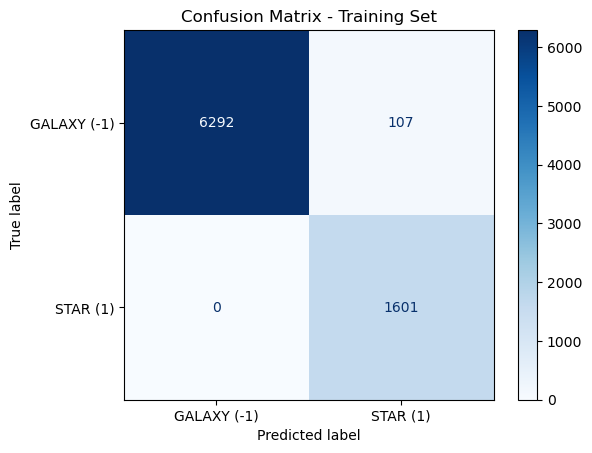

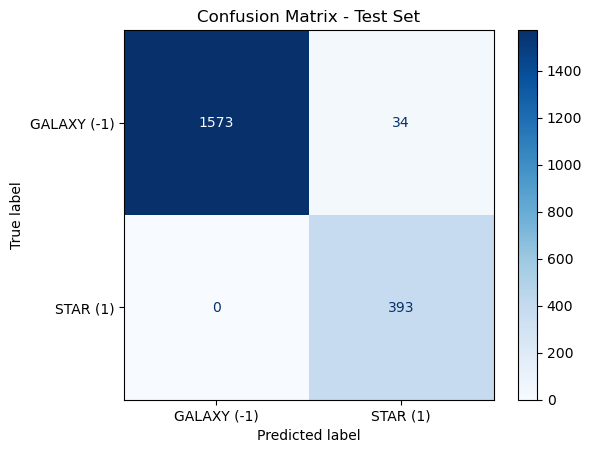

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Training set Confusion Matrix
cm_train = confusion_matrix(binary_train['class'].values, predictions_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['GALAXY (-1)', 'STAR (1)'])
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Set')
plt.show()

# Test set Confusion Matrix
cm_test = confusion_matrix(binary_test['class'].values, predictions_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['GALAXY (-1)', 'STAR (1)'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Set')
plt.show()

## Falsos/verdaderos positivos/negativos

En un problema de clasificación binaria, las predicciones pueden clasificarse en cuatro categorías. Un **verdadero positivo (TP)** ocurre cuando el modelo predice correctamente la presencia de una clase positiva. Un **verdadero negativo (TN)** ocurre cuando predice correctamente la ausencia de dicha clase. Un **falso positivo (FP)** corresponde a un caso en el que el modelo predice una clase positiva cuando en realidad es negativa, mientras que un **falso negativo (FN)** ocurre cuando el modelo no detecta una clase positiva que sí estaba presente.

## Métricas: Precision/Recall

La **precision** mide qué fracción de las predicciones positivas realizadas por el modelo son correctas. Un valor alto de precision indica que hay pocos falsos positivos. El **recall** (o sensibilidad) mide qué fracción de los casos positivos reales es detectada correctamente por el modelo. Un valor alto de recall indica que hay pocos falsos negativos. Mientras que la precision responde a la pregunta "¿cuántas de las detecciones son correctas?", el recall responde a "¿cuántos de los casos reales fueron detectados?".

$$
\mathrm{Precision}=\frac{TP}{TP+FP}
$$

$$
\mathrm{Recall}=\frac{TP}{TP+FN}
$$

## Métricas: el F1-score

El **F1-score** es una métrica que combina **precision** y **recall** en un único valor. Corresponde a la media armónica de ambas métricas, por lo que solo toma valores altos cuando tanto la precision como el recall son elevados. Es especialmente útil cuando existe desbalance entre clases o cuando se desea un equilibrio entre falsos positivos y falsos negativos.

$$
F_1 =
2\,
\frac{\mathrm{Precision}\times\mathrm{Recall}}
{\mathrm{Precision}+\mathrm{Recall}}
$$

Un valor de \(F_1=1\) indica clasificación perfecta, mientras que \(F_1=0\) corresponde al peor desempeño posible.

**Nota:** En el caso general (multi-clase) cada clase tiene asociadas métricas de precision/recall. El diagnóstico de un modelo involucra promediar sobre todas las clases, pero si las clases no están bien distribuidas (situación muy común) esto puede llevar a overfitting.

In [12]:
from sklearn.metrics import f1_score

f1_train = f1_score(binary_train['class'].values, predictions_train)
f1_test = f1_score(binary_test['class'].values, predictions_test)

print(f"F1-score (Train): {f1_train:.4f}")
print(f"F1-score (Test): {f1_test:.4f}")



F1-score (Train): 0.9677
F1-score (Test): 0.9585


### Feature Importance (Importancia de Variables)

La magnitud de la ponderación asociada a cada *feature* (variable) indica su importancia en el proceso de decisión del algoritmo a la hora de clasificar. Entre mayor sea la ponderación, es más importante para separar las clases.

Feature Importances (Absolute Weights):
redshift    24.572943
u            0.479027
MJD          0.147531
z            0.139114
plate        0.104003
i            0.040427
r            0.034570
delta        0.018282
fiber_ID     0.017041
g            0.016018
alpha        0.002191
dtype: float64


/var/folders/2y/t3gprvl52s75ccs56z7ml0s80000gn/T/ipykernel_24040/1769717404.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_sorted.values, y=feature_importance_sorted.index, palette='viridis')


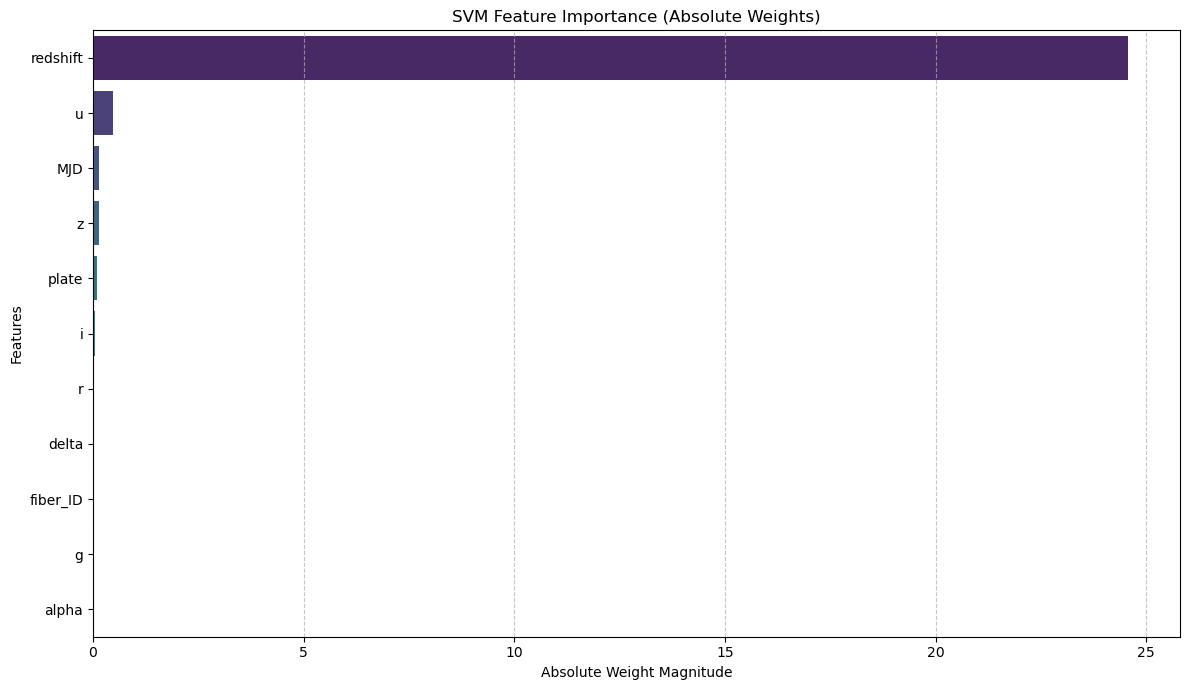

In [13]:
import seaborn as sns

feature_names = X.columns

# The absolute value of weights indicates importance for linear models
feature_importance = pd.Series(np.abs(weights), index=feature_names)

# Sort the features by importance in descending order
feature_importance_sorted = feature_importance.sort_values(ascending=False)

print("Feature Importances (Absolute Weights):")
print(feature_importance_sorted)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_sorted.values, y=feature_importance_sorted.index, palette='viridis')
plt.title('SVM Feature Importance (Absolute Weights)')
plt.xlabel('Absolute Weight Magnitude')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Receiver Operating Characteristic (ROC)

Para evaluar más el clasificador, el analisis de Característica Operativa del Receptor nos entrega una medida de la calidad de la clasificación a través de distintos umbrales de clasificación. Graficamos el True Positive Rate (TPR) contra el False Positive Rate (FPR) para distintos umbrales. El área bajo la curva (AUC) entrega una medida escalar de la calidad del clasificador..

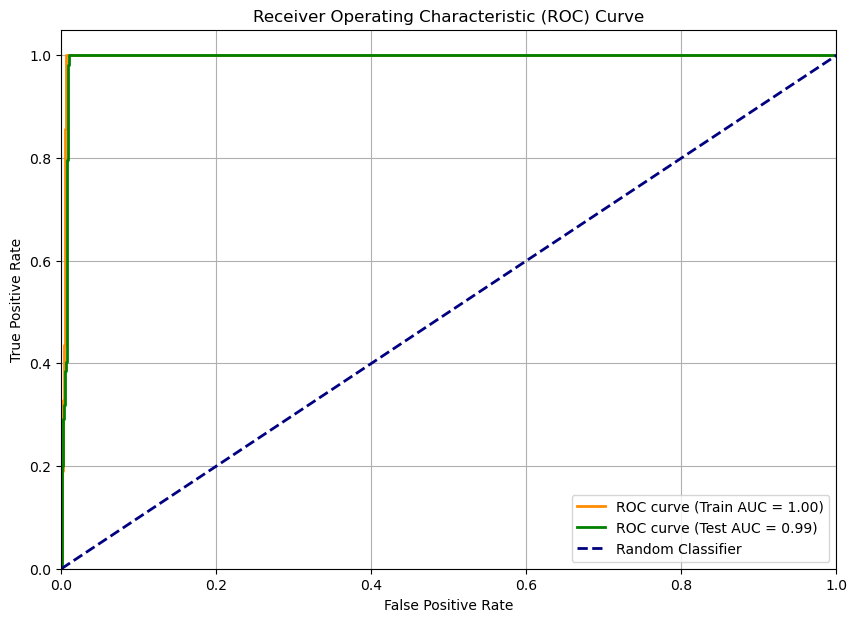

AUC for Training Set: 0.9964
AUC for Test Set: 0.9945


In [14]:
from sklearn.metrics import roc_curve, auc

# Helper function to get raw decision scores
def get_decision_scores(X, w, b):
    if isinstance(X, pd.DataFrame):
        X = X.values
    return np.dot(X, w) + b

# Get decision scores for training and test sets
decision_scores_train = get_decision_scores(binary_train.drop('class', axis=1), weights, bias)
decision_scores_test = get_decision_scores(binary_test.drop('class', axis=1), weights, bias)

# For ROC analysis, the true labels should be 0 and 1.
true_labels_train = binary_train['class'].apply(lambda x: 1 if x == 1 else 0)
true_labels_test = binary_test['class'].apply(lambda x: 1 if x == 1 else 0)

# Calculate ROC curve and AUC for training set
fpr_train, tpr_train, _ = roc_curve(true_labels_train, decision_scores_train)
roc_auc_train = auc(fpr_train, tpr_train)

# Calculate ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(true_labels_test, decision_scores_test)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting the ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'ROC curve (Train AUC = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='green', lw=2, label=f'ROC curve (Test AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC for Training Set: {roc_auc_train:.4f}")
print(f"AUC for Test Set: {roc_auc_test:.4f}")

### Análisis de las curvas de Precision-Recall

Las **curvas Precision–Recall** son útiles para evaluar el desempeño de clasificadores binarios, especialmente cuando las clases están desbalanceadas. Estas curvas representan la **precision** (la proporción de identificaciones positivas que realmente son correctas) en función del **recall** (la proporción de casos positivos reales que fueron identificados correctamente) para diferentes valores del umbral de decisión. El **área bajo la curva Precision–Recall** (*Average Precision*, AP) resume este compromiso entre precision y recall en un único valor.

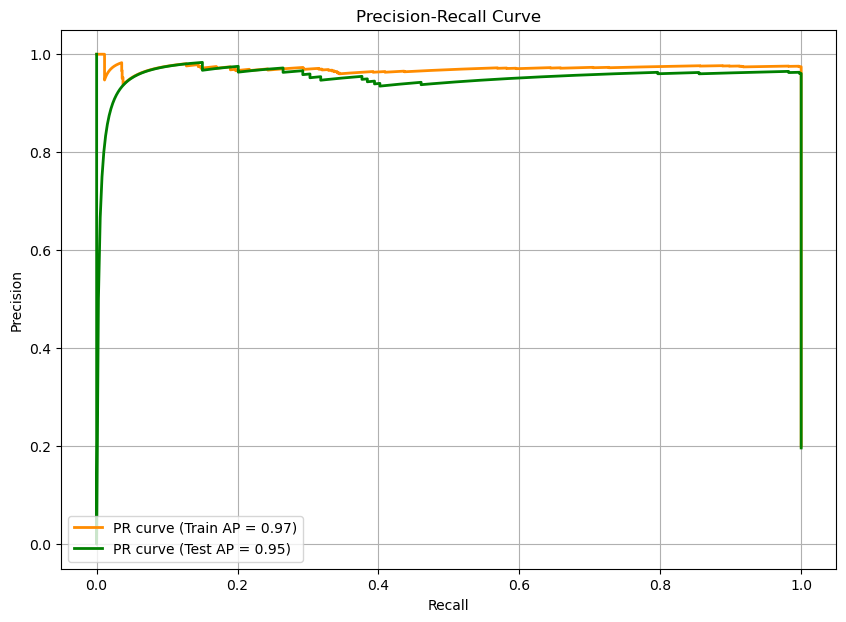

Average Precision for Training Set: 0.9711
Average Precision for Test Set: 0.9537


In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curve and Average Precision for training set
precision_train, recall_train, _ = precision_recall_curve(true_labels_train, decision_scores_train)
ap_train = average_precision_score(true_labels_train, decision_scores_train)

# Calculate Precision-Recall curve and Average Precision for test set
precision_test, recall_test, _ = precision_recall_curve(true_labels_test, decision_scores_test)
ap_test = average_precision_score(true_labels_test, decision_scores_test)

plt.figure(figsize=(10, 7))
plt.plot(recall_train, precision_train, color='darkorange', lw=2, label=f'PR curve (Train AP = {ap_train:.2f})')
plt.plot(recall_test, precision_test, color='green', lw=2, label=f'PR curve (Test AP = {ap_test:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"Average Precision for Training Set: {ap_train:.4f}")
print(f"Average Precision for Test Set: {ap_test:.4f}")

### Clasificación multi.clase con SVM usando `sklearn.svm.SVC`

Para clasificación multiclase, utilizaremos `SVC` (*Support Vector Classifier*) de scikit-learn, que extiende el concepto de las Máquinas de Vectores de Soporte (SVM) para manejar más de dos clases. Prepararemos los datos, entrenaremos el modelo y evaluaremos su desempeño utilizando un informe de clasificación (*classification report*).

In [16]:
multi_train, multi_test = scaled_df[:8000], scaled_df[8000:]
y_test_multi = multi_test['class']

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X_train_multi = multi_train.drop('class', axis=1)
y_train_multi = multi_train['class']

X_test_multi = multi_test.drop('class', axis=1)
# y_test_multi is already defined from previous step

# Using 'linear' kernel as our previous custom SVM was linear.
# For complex, non-linear boundaries, other kernels like 'rbf' can be used.
multi_svm_model = SVC(kernel='linear', random_state=42)
multi_svm_model.fit(X_train_multi, y_train_multi)

predictions_train_multi = multi_svm_model.predict(X_train_multi)
predictions_test_multi = multi_svm_model.predict(X_test_multi)

print("\n--- Multiclass SVM Classification Report (Training Set) ---")
print(classification_report(y_train_multi, predictions_train_multi))

print("\n--- Multiclass SVM Classification Report (Test Set) ---")
print(classification_report(y_test_multi, predictions_test_multi))


--- Multiclass SVM Classification Report (Training Set) ---
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96      4816
         QSO       0.96      0.88      0.91      1583
        STAR       0.92      1.00      0.96      1601

    accuracy                           0.95      8000
   macro avg       0.95      0.95      0.94      8000
weighted avg       0.95      0.95      0.95      8000


--- Multiclass SVM Classification Report (Test Set) ---
              precision    recall  f1-score   support

      GALAXY       0.97      0.95      0.96      1275
         QSO       0.95      0.89      0.92       332
        STAR       0.90      1.00      0.95       393

    accuracy                           0.95      2000
   macro avg       0.94      0.95      0.94      2000
weighted avg       0.95      0.95      0.95      2000



**Ejercicio**: Visualice las matrices de confusión resultantes.

### Análisis ROC para SVM multiclase

Las curvas ROC se utilizan típicamente en problemas de clasificación binaria. Sin embargo, para problemas multiclase, una estrategia común consiste en extender el análisis ROC mediante un enfoque *one-vs-rest* (OvR) o *one-vs-one* (OvO).

En este caso utilizaremos un enfoque *one-vs-rest* (OvR), en el que cada clase se considera temporalmente como la clase positiva, mientras que todas las demás se agrupan como una única clase negativa. Esto permite calcular una curva ROC y un valor AUC para cada clase de manera individual.

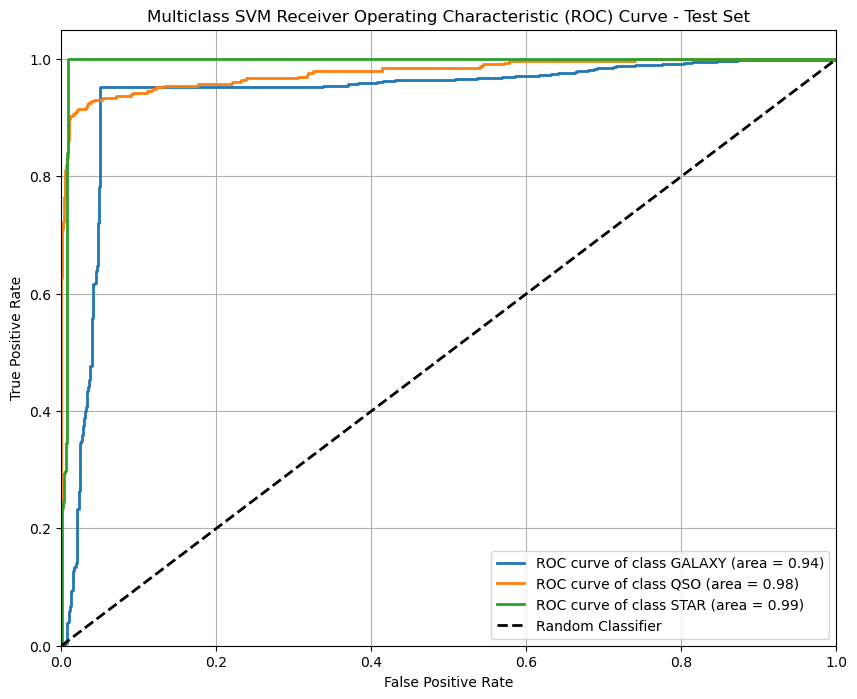


AUC for each class:
Class GALAXY: 0.9381
Class QSO: 0.9778
Class STAR: 0.9943


In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc # Added roc_curve and auc import

# Get class labels from the trained multiclass SVM model
class_labels = multi_svm_model.classes_ # Defined class_labels

# Binarize the output for OvR strategy
y_test_multi_bin = label_binarize(y_test_multi, classes=class_labels)
y_score_multi = multi_svm_model.decision_function(X_test_multi)

# Compute ROC curve and ROC area for each class
n_classes = len(class_labels)
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_multi_bin[:, i], y_score_multi[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass SVM Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("\nAUC for each class:")
for i in range(n_classes):
    print(f"Class {class_labels[i]}: {roc_auc[i]:.4f}")

### Importancia de variables en SVM multiclase

Para modelos SVM lineales, la magnitud absoluta de los coeficientes (`coef_`) puede interpretarse como una medida de la importancia de las variables. Un coeficiente con mayor valor absoluto indica una mayor influencia de esa variable sobre la frontera de decisión del modelo. En problemas multiclase, se pueden sumar los valores absolutos de los coeficientes correspondientes a todas las clases para cada variable, obteniendo así una medida agregada de su importancia.

Feature Importances for Multiclass SVM (Sum of Absolute Coefficients):
redshift    29.060018
u            3.586718
g            3.270577
r            2.133163
i            1.962464
z            1.090545
plate        0.605540
MJD          0.476094
delta        0.152632
alpha        0.052643
fiber_ID     0.014386
dtype: float64


/var/folders/2y/t3gprvl52s75ccs56z7ml0s80000gn/T/ipykernel_24040/3978924218.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_multi_sorted.values, y=feature_importance_multi_sorted.index, palette='viridis')


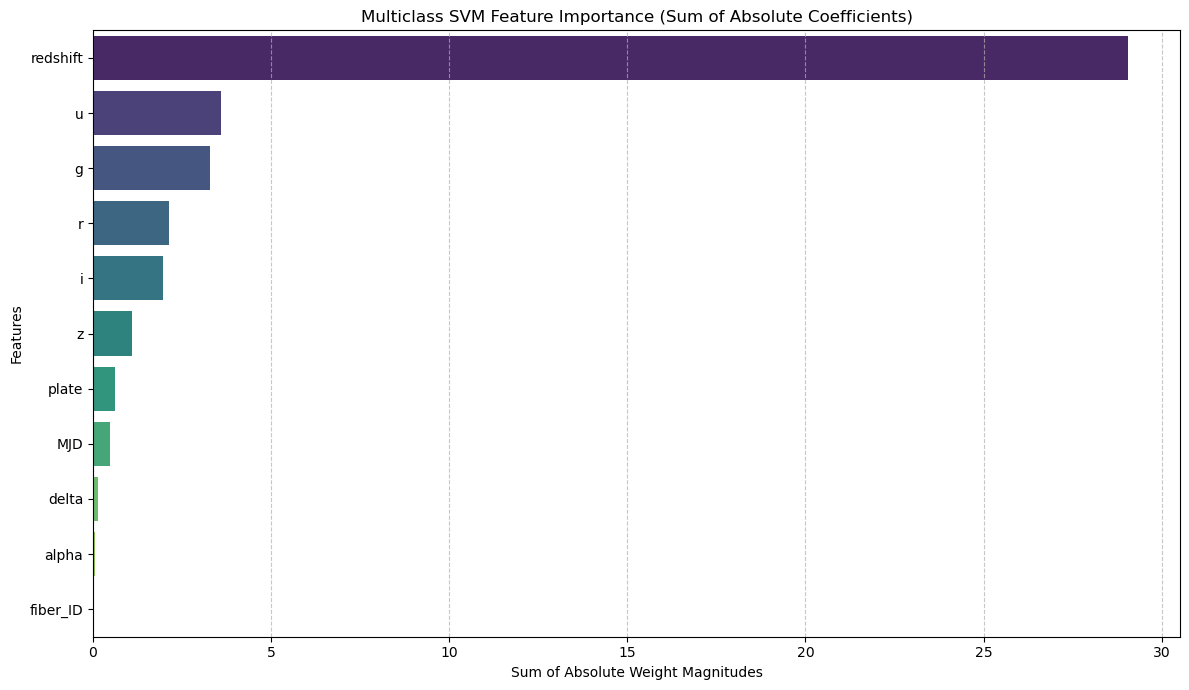

In [19]:
feature_names_multi = X_train_multi.columns

# Get the coefficients from the trained multiclass SVM model
# multi_svm_model.coef_ has shape (n_classes, n_features)
coef_multi = multi_svm_model.coef_

# Calculate the sum of absolute coefficients for each feature across all classes
# This gives an aggregated importance for each feature
feature_importance_multi = pd.Series(np.sum(np.abs(coef_multi), axis=0), index=feature_names_multi)

feature_importance_multi_sorted = feature_importance_multi.sort_values(ascending=False)

print("Feature Importances for Multiclass SVM (Sum of Absolute Coefficients):")
print(feature_importance_multi_sorted)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_multi_sorted.values, y=feature_importance_multi_sorted.index, palette='viridis')
plt.title('Multiclass SVM Feature Importance (Sum of Absolute Coefficients)')
plt.xlabel('Sum of Absolute Weight Magnitudes')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Clasificación mediante árboles de decisión

Ahora aplicaremos un clasificador basado en árboles de decisión a nuestro problema de clasificación multiclase. Los árboles de decisión son métodos supervisados no paramétricos utilizados tanto para clasificación como para regresión. Su objetivo es construir un modelo que prediga el valor de una variable objetivo mediante el aprendizaje de reglas de decisión simples inferidas a partir de las variables de entrada.

Los árboles de decisión tienden a hacer overfitting sobre el conjunto de entrenamiento, por lo que los resultados con el conjunto de test no son tan buenos.

In [20]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train_multi, y_train_multi)

predictions_train_dt = decision_tree_model.predict(X_train_multi)
predictions_test_dt = decision_tree_model.predict(X_test_multi)

print("\n--- Decision Tree Classification Report (Training Set) ---")
print(classification_report(y_train_multi, predictions_train_dt))

print("\n--- Decision Tree Classification Report (Test Set) ---")
print(classification_report(y_test_multi, predictions_test_dt))


--- Decision Tree Classification Report (Training Set) ---


              precision    recall  f1-score   support

      GALAXY       1.00      1.00      1.00      4816
         QSO       1.00      1.00      1.00      1583
        STAR       1.00      1.00      1.00      1601

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


--- Decision Tree Classification Report (Test Set) ---
              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.97      1275
         QSO       0.89      0.93      0.91       332
        STAR       0.99      1.00      0.99       393

    accuracy                           0.97      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



**Ejercicio**: Visualice la matriz de confusión para el test set.

Ahora hagamos un análisis de *feature importance*.

Feature Importances for Decision Tree:
redshift    0.873102
g           0.036591
u           0.036364
z           0.009219
fiber_ID    0.007411
alpha       0.007307
MJD         0.007020
r           0.006823
delta       0.006237
i           0.005372
plate       0.004554
dtype: float64


/var/folders/2y/t3gprvl52s75ccs56z7ml0s80000gn/T/ipykernel_24040/2959764395.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_dt_sorted.values, y=feature_importance_dt_sorted.index, palette='viridis')


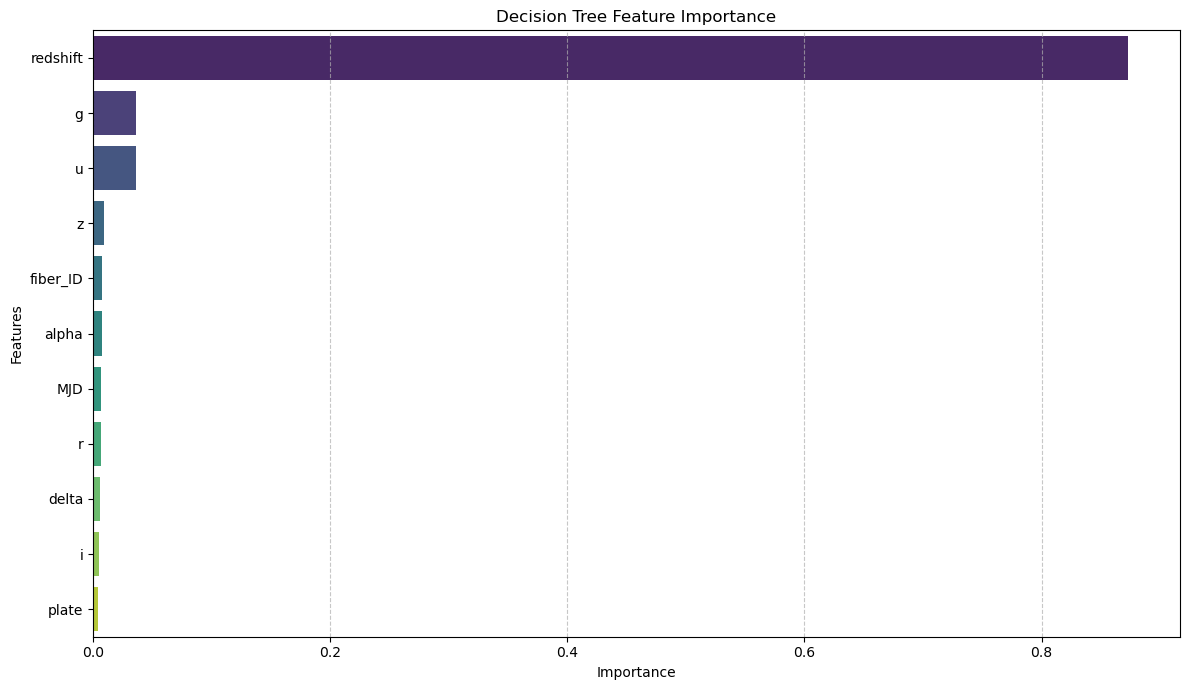

In [21]:
feature_importances_dt = decision_tree_model.feature_importances_

feature_names_multi = X_train_multi.columns
feature_importance_dt_series = pd.Series(feature_importances_dt, index=feature_names_multi)

feature_importance_dt_sorted = feature_importance_dt_series.sort_values(ascending=False)

print("Feature Importances for Decision Tree:")
print(feature_importance_dt_sorted)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_dt_sorted.values, y=feature_importance_dt_sorted.index, palette='viridis')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Clasificación mediante Random Forest

Los **Random Forests** son un método de aprendizaje por conjuntos (*ensemble learning*) para clasificación (y regresión) que funciona construyendo múltiples árboles de decisión durante el entrenamiento. En problemas de clasificación, la predicción final corresponde a la clase más votada entre todos los árboles, mientras que en regresión corresponde al promedio de las predicciones individuales. Este enfoque ayuda a corregir la tendencia de los árboles de decisión a sobreajustarse a los datos de entrenamiento.

In [22]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators = number of trees
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

random_forest_model.fit(X_train_multi, y_train_multi)

predictions_train_rf = random_forest_model.predict(X_train_multi)
predictions_test_rf = random_forest_model.predict(X_test_multi)

print("\n--- Random Forest Classification Report (Training Set) ---")
print(classification_report(y_train_multi, predictions_train_rf))

print("\n--- Random Forest Classification Report (Test Set) ---")
print(classification_report(y_test_multi, predictions_test_rf))


--- Random Forest Classification Report (Training Set) ---
              precision    recall  f1-score   support

      GALAXY       1.00      1.00      1.00      4816
         QSO       1.00      1.00      1.00      1583
        STAR       1.00      1.00      1.00      1601

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


--- Random Forest Classification Report (Test Set) ---
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      1275
         QSO       0.96      0.93      0.95       332
        STAR       0.98      1.00      0.99       393

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 800x600 with 0 Axes>

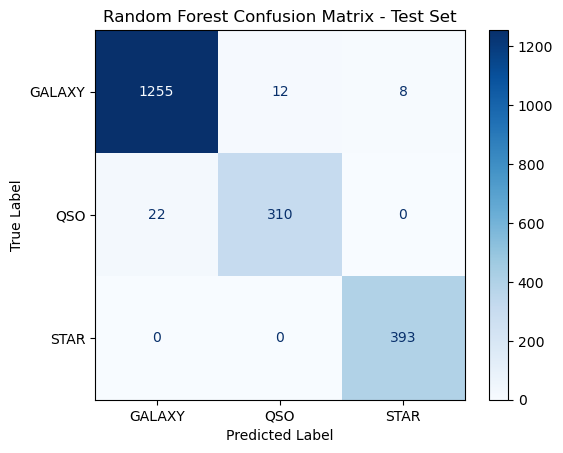

In [23]:
class_labels_rf = y_test_multi.unique()
class_labels_rf.sort() # Ensure consistent order

cm_rf = confusion_matrix(y_test_multi, predictions_test_rf, labels=class_labels_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_labels_rf)

plt.figure(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Random Forest Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Clasificación mediante regresión logística

La **regresión logística** es un modelo estadístico que, en su forma básica, utiliza una función logística (similar a una función paso) para modelar una variable dependiente binaria, aunque también puede extenderse para manejar problemas multiclase. Se trata de un modelo lineal que estima la probabilidad de que una instancia pertenezca a una clase determinada.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 'lbfgs' is the selected optimization algorithm
logistic_regression_model = LogisticRegression(solver='lbfgs', multi_class='auto', random_state=42, max_iter=1000)

logistic_regression_model.fit(X_train_multi, y_train_multi)

predictions_train_lr = logistic_regression_model.predict(X_train_multi)
predictions_test_lr = logistic_regression_model.predict(X_test_multi)

print("\n--- Logistic Regression Classification Report (Training Set) ---")
print(classification_report(y_train_multi, predictions_train_lr))

print("\n--- Logistic Regression Classification Report (Test Set) ---")
print(classification_report(y_test_multi, predictions_test_lr))


--- Logistic Regression Classification Report (Training Set) ---
              precision    recall  f1-score   support

      GALAXY       0.95      0.96      0.96      4816
         QSO       0.96      0.86      0.91      1583
        STAR       0.93      0.99      0.96      1601

    accuracy                           0.95      8000
   macro avg       0.95      0.94      0.94      8000
weighted avg       0.95      0.95      0.95      8000


--- Logistic Regression Classification Report (Test Set) ---
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96      1275
         QSO       0.94      0.88      0.91       332
        STAR       0.91      0.99      0.95       393

    accuracy                           0.95      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.95      0.95      0.95      2000



/opt/homebrew/Caskroom/miniconda/base/envs/jupyter-book/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Importancia de variables en regresión logística

En la regresión logística, la magnitud absoluta de los coeficientes (`coef_`) puede interpretarse como una medida de la importancia de las variables (features). Un coeficiente con mayor valor absoluto indica una mayor influencia de esa variable sobre la frontera de decisión del modelo. En problemas multiclase, se pueden analizar los coeficientes correspondientes a cada clase por separado o utilizar la suma agregada de los valores absolutos de los coeficientes para obtener una medida global de importancia.

Feature Importances for Logistic Regression (Sum of Absolute Coefficients):
redshift    34.189073
u           10.644284
g            7.169565
r            4.190732
i            3.751013
z            2.656094
MJD          1.597761
plate        1.008712
delta        0.260061
fiber_ID     0.090847
alpha        0.078052
dtype: float64


/var/folders/2y/t3gprvl52s75ccs56z7ml0s80000gn/T/ipykernel_24040/942836711.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_lr_sorted.values, y=feature_importance_lr_sorted.index, palette='viridis')


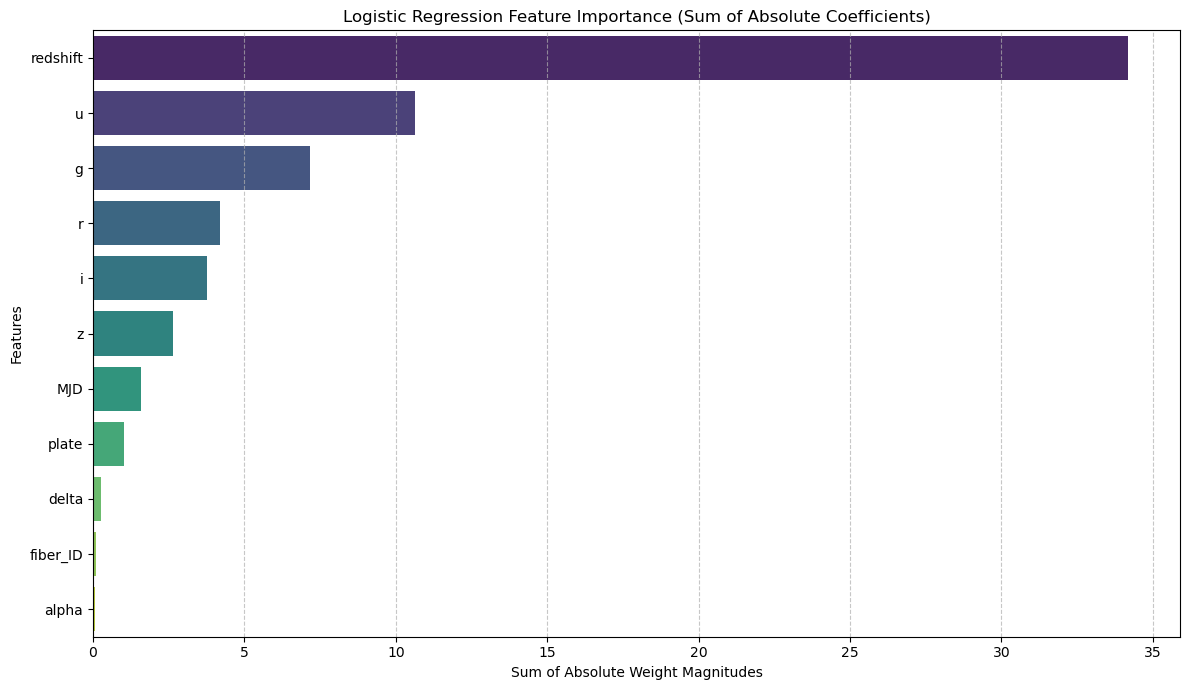

In [25]:
feature_names_lr = X_train_multi.columns

# logistic_regression_model.coef_ has shape (n_classes, n_features)
coef_lr = logistic_regression_model.coef_

# Calculate the sum of absolute coefficients for each feature across all classes
# This gives an aggregated importance for each feature
feature_importance_lr = pd.Series(np.sum(np.abs(coef_lr), axis=0), index=feature_names_lr)

feature_importance_lr_sorted = feature_importance_lr.sort_values(ascending=False)

print("Feature Importances for Logistic Regression (Sum of Absolute Coefficients):")
print(feature_importance_lr_sorted)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_lr_sorted.values, y=feature_importance_lr_sorted.index, palette='viridis')
plt.title('Logistic Regression Feature Importance (Sum of Absolute Coefficients)')
plt.xlabel('Sum of Absolute Weight Magnitudes')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualización de la frontera de decisión en regresión logística

Para comprender cómo el modelo de regresión logística clasifica los distintos objetos astronómicos, visualizaremos sus fronteras de decisión en un espacio bidimensional utilizando las dos variables más influyentes: `redshift` y `u`.

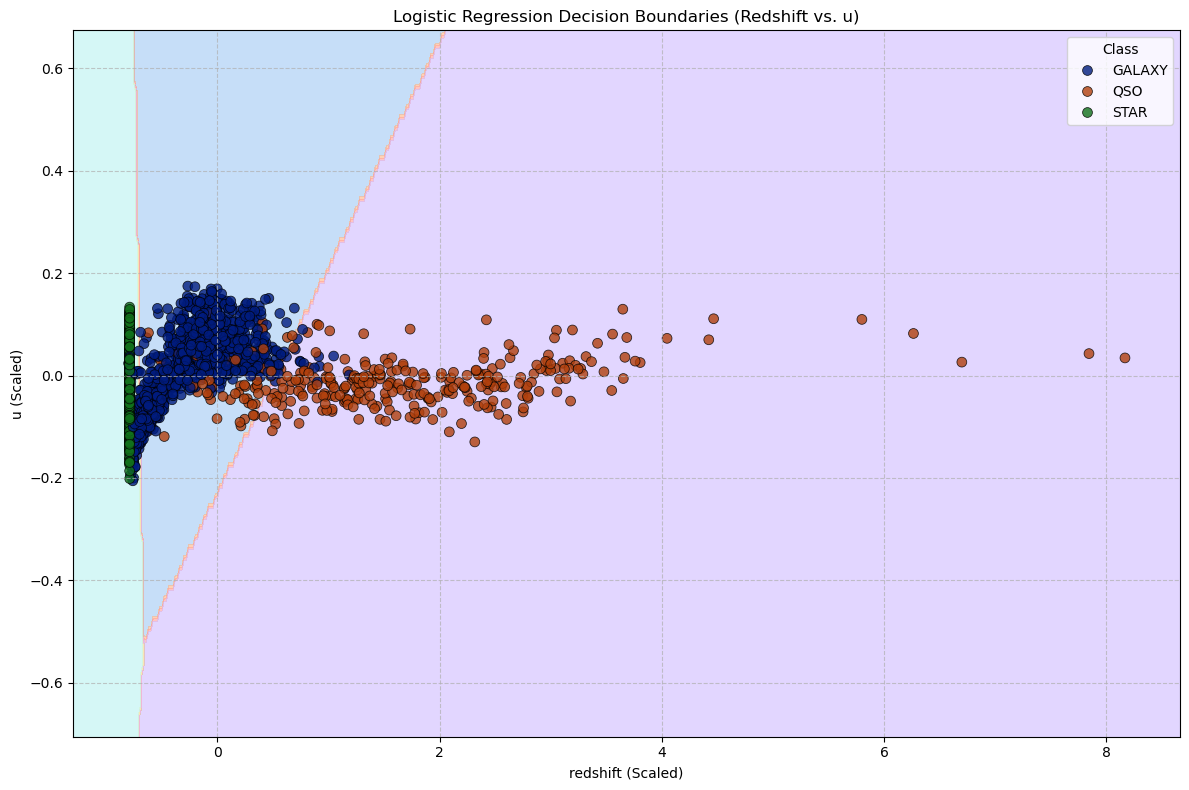

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

feature1 = 'redshift'
feature2 = 'u'

X_plot = X_test_multi[[feature1, feature2]]
y_plot = y_test_multi

# Create a meshgrid to plot the decision boundaries
x_min, x_max = X_plot[feature1].min() - 0.5, X_plot[feature1].max() + 0.5
y_min, y_max = X_plot[feature2].min() - 0.5, X_plot[feature2].max() + 0.5
h = 0.02  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Create a DataFrame for the meshgrid points
# It must have all the features that the model was trained on
# Fill with mean values for other features to keep them constant
# X_train_multi contains all original scaled features
full_meshgrid_df = pd.DataFrame(np.tile(X_train_multi.mean().values, (xx.size, 1)), columns=X_train_multi.columns)

# Fill the 'redshift' and 'u' columns with the meshgrid values
full_meshgrid_df[feature1] = xx.ravel()
full_meshgrid_df[feature2] = yy.ravel()

# Predict class for each point in the meshgrid using the full feature set
# Map the class labels to numerical values for plotting colors
class_to_int = {cls: i for i, cls in enumerate(logistic_regression_model.classes_)}
int_to_class = {i: cls for i, cls in enumerate(logistic_regression_model.classes_)}

Z_pred = logistic_regression_model.predict(full_meshgrid_df)
Z_numeric = np.array([class_to_int[c] for c in Z_pred])
Z = Z_numeric.reshape(xx.shape)

cmp_light = ListedColormap(sns.color_palette("pastel").as_hex())
cmp_dark = ListedColormap(sns.color_palette("dark").as_hex())

plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, cmap=cmp_light, alpha=0.6)

sns.scatterplot(
    x=X_plot[feature1],
    y=X_plot[feature2],
    hue=y_plot,
    palette='dark',
    alpha=0.8,
    edgecolor='k',
    s=50,
    ax=plt.gca()
)

plt.xlabel(f'{feature1} (Scaled)')
plt.ylabel(f'{feature2} (Scaled)')
plt.title('Logistic Regression Decision Boundaries (Redshift vs. u)')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

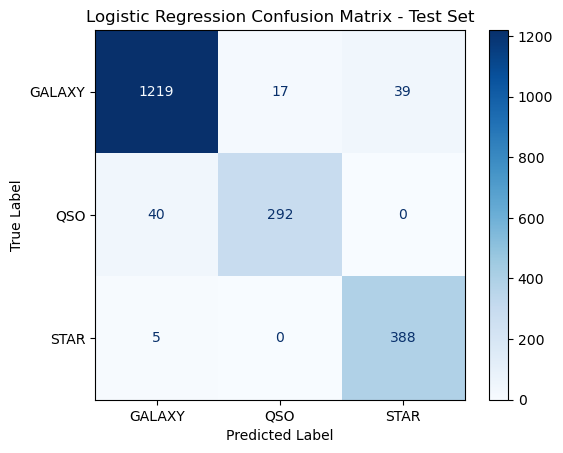

In [27]:
cm_lr = confusion_matrix(y_test_multi, predictions_test_lr, labels=class_labels_rf)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_labels_rf)

plt.figure(figsize=(8, 6))
disp_lr.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Logistic Regression Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()